In [1]:
# Import all required libraries
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from ultralytics import YOLO
import google.genai as genai
import os
import io
import base64

print("✅ All libraries imported successfully!")

ModuleNotFoundError: No module named 'google.genai'

In [2]:
!pip install google-genai

  Obtaining dependency information for google-genai from https://files.pythonhosted.org/packages/b4/6e/aa6b30b09f58b946750fc4089c5248fbd3576f746e0e818d88633559dc84/google_genai-2.3.0-py3-none-any.whl.metadata
     ---------------------------------------- 0.0/52.7 kB ? eta -:--:--
     ---------------------------------------- 0.0/52.7 kB ? eta -:--:--
     ---------------------------------------- 0.0/52.7 kB ? eta -:--:--
     ------- -------------------------------- 10.2/52.7 kB ? eta -:--:--
     ------- -------------------------------- 10.2/52.7 kB ? eta -:--:--
     -------------- ----------------------- 20.5/52.7 kB 110.1 kB/s eta 0:00:01
     ----------------------------- -------- 41.0/52.7 kB 179.6 kB/s eta 0:00:01
     -------------------------------------- 52.7/52.7 kB 209.2 kB/s eta 0:00:00
  Obtaining dependency information for distro<2,>=1.7.0 from https://files.pythonhosted.org/packages/12/b3/231ffd4ab1fc9d679809f356cebee130ac7daa00d6d6f3206dd4fd137e9e/distro-1.9.0-py3-none


[notice] A new release of pip is available: 23.2.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
import cv2
import numpy as np
from PIL import Image
import matplotlib.pyplot as plt
from ultralytics import YOLO
import google.genai as genai
import os
import io
import base64

print("✅ All libraries imported successfully!")

✅ All libraries imported successfully!


In [4]:
# Loading the pre-trained YOLOv8 model
model = YOLO("yolov8n.pt")

print("✅ YOLOv8 model loaded successfully!")
print(f"   Model type : YOLOv8 Nano")
print(f"   Classes    : {len(model.names)} objects it can detect")
print(f"\nSome objects it can detect:")
# Print first 20 class names
for i, name in enumerate(model.names.values()):
    if i < 20:
        print(f"   {i+1}. {name}")

✅ YOLOv8 model loaded successfully!
   Model type : YOLOv8 Nano
   Classes    : 80 objects it can detect

Some objects it can detect:
   1. person
   2. bicycle
   3. car
   4. motorcycle
   5. airplane
   6. bus
   7. train
   8. truck
   9. boat
   10. traffic light
   11. fire hydrant
   12. stop sign
   13. parking meter
   14. bench
   15. bird
   16. cat
   17. dog
   18. horse
   19. sheep
   20. cow


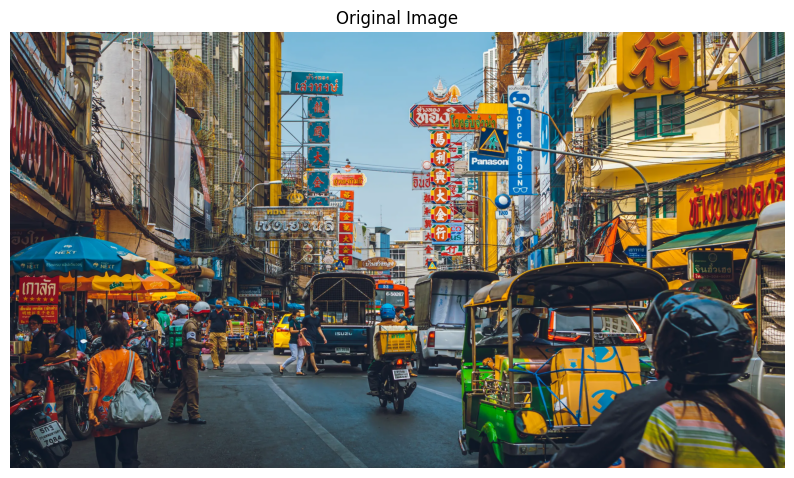

✅ Image loaded successfully!
   Size   : 2560 x 1440 pixels
   Mode   : RGB


In [5]:
# Load and display the test image
image_path = "test.jpg"

# Open image using PIL
image = Image.open(image_path)

# Convert to RGB (in case it's RGBA or grayscale)
image = image.convert("RGB")

# Display the image
plt.figure(figsize=(10, 6))
plt.imshow(image)
plt.axis("off")
plt.title("Original Image")
plt.show()

print(f"✅ Image loaded successfully!")
print(f"   Size   : {image.size[0]} x {image.size[1]} pixels")
print(f"   Mode   : {image.mode}")

In [6]:
# Run YOLOv8 object detection on the image
results = model(image)

# Get the first result
result = results[0]

# Print detected objects
print("✅ Object Detection Complete!")
print(f"\nDetected {len(result.boxes)} objects:\n")

for box in result.boxes:
    # Get class name
    class_id = int(box.cls[0])
    class_name = model.names[class_id]
    
    # Get confidence score
    confidence = float(box.conf[0]) * 100
    
    # Get bounding box coordinates
    x1, y1, x2, y2 = map(int, box.xyxy[0])
    
    print(f"   🔍 {class_name} — Confidence: {confidence:.1f}% — Box: ({x1}, {y1}) to ({x2}, {y2})")


0: 384x640 8 persons, 1 motorcycle, 4 buss, 1 train, 1 truck, 2 traffic lights, 1 umbrella, 1 handbag, 147.3ms
Speed: 5.2ms preprocess, 147.3ms inference, 3.6ms postprocess per image at shape (1, 3, 384, 640)
✅ Object Detection Complete!

Detected 19 objects:

   🔍 bus — Confidence: 82.4% — Box: (1333, 787) to (1612, 1125)
   🔍 person — Confidence: 73.6% — Box: (242, 958) to (488, 1435)
   🔍 person — Confidence: 68.8% — Box: (1758, 855) to (2558, 1429)
   🔍 bus — Confidence: 66.3% — Box: (1474, 753) to (2186, 1431)
   🔍 person — Confidence: 63.9% — Box: (521, 894) to (654, 1291)
   🔍 person — Confidence: 49.2% — Box: (949, 906) to (1037, 1133)
   🔍 umbrella — Confidence: 47.4% — Box: (0, 664) to (454, 1006)
   🔍 bus — Confidence: 42.9% — Box: (960, 793) to (1212, 1122)
   🔍 person — Confidence: 41.8% — Box: (654, 902) to (722, 1114)
   🔍 handbag — Confidence: 38.8% — Box: (322, 1045) to (503, 1304)
   🔍 traffic light — Confidence: 36.7% — Box: (2006, 4) to (2261, 204)
   🔍 truck — Con

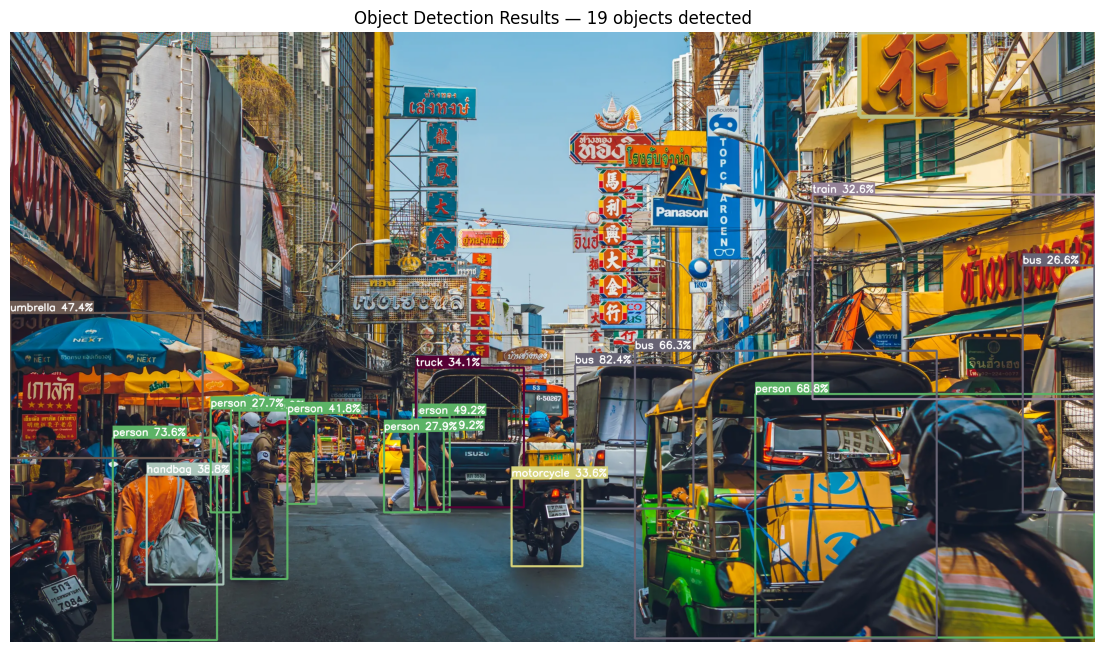

✅ Bounding boxes drawn successfully!


In [7]:
# Convert PIL image to OpenCV format (BGR)
image_cv = cv2.cvtColor(np.array(image), cv2.COLOR_RGB2BGR)

# Define colors for different classes
colors = {}
np.random.seed(42)
for class_id in model.names:
    colors[class_id] = tuple(np.random.randint(0, 255, 3).tolist())

# Draw bounding boxes on the image
for box in result.boxes:
    class_id = int(box.cls[0])
    class_name = model.names[class_id]
    confidence = float(box.conf[0]) * 100
    x1, y1, x2, y2 = map(int, box.xyxy[0])
    color = colors[class_id]

    # Draw rectangle
    cv2.rectangle(image_cv, (x1, y1), (x2, y2), color, 3)

    # Draw label background
    label = f"{class_name} {confidence:.1f}%"
    (w, h), _ = cv2.getTextSize(label, cv2.FONT_HERSHEY_SIMPLEX, 0.8, 2)
    cv2.rectangle(image_cv, (x1, y1 - h - 10), (x1 + w, y1), color, -1)

    # Draw label text
    cv2.putText(image_cv, label, (x1, y1 - 5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.8, (255, 255, 255), 2)

# Convert back to RGB for display
image_result = cv2.cvtColor(image_cv, cv2.COLOR_BGR2RGB)

# Display the result
plt.figure(figsize=(14, 8))
plt.imshow(image_result)
plt.axis("off")
plt.title(f"Object Detection Results — {len(result.boxes)} objects detected")
plt.show()

print("✅ Bounding boxes drawn successfully!")

In [9]:
# Set up Gemini API
from dotenv import load_dotenv

load_dotenv()

# Initialize Gemini client
GOOGLE_API_KEY = os.getenv("GOOGLE_API_KEY")

client = genai.Client(api_key=GOOGLE_API_KEY)

print("✅ Gemini API initialized successfully!")

✅ Gemini API initialized successfully!


In [12]:
# Convert image to bytes for Gemini
img_byte_arr = io.BytesIO()
image.save(img_byte_arr, format='JPEG')
img_bytes = img_byte_arr.getvalue()

# Get detected object names for context
detected_objects = []
for box in result.boxes:
    class_id = int(box.cls[0])
    class_name = model.names[class_id]
    confidence = float(box.conf[0]) * 100
    detected_objects.append(f"{class_name} ({confidence:.1f}%)")

objects_text = ", ".join(detected_objects)

# Create prompt for Gemini
prompt = f"""
You are an intelligent image analysis assistant.

The following objects were detected in the image by YOLOv8:
{objects_text}

Based on the image and detected objects, please provide:
1. A detailed description of the scene
2. What is happening in the image
3. The overall context and setting

Keep the description natural and conversational.
"""

# Send image + prompt to Gemini
response = client.models.generate_content(
    model="gemini-2.5-flash",
    contents=[
        {
            "parts": [
                {"text": prompt},
                {"inline_data": {"mime_type": "image/jpeg", "data": base64.b64encode(img_bytes).decode()}}
            ]
        }
    ]
)

print("✅ Scene Description Generated!")
print("\n" + "="*50)
print(response.text)
print("="*50)

✅ Scene Description Generated!

This image captures a truly vibrant and bustling street scene, likely in a city in Southeast Asia, possibly Thailand, given the architecture, vehicles like tuk-tuks, and the script on the many signs.

**1. A detailed description of the scene:**
The scene is a lively, crowded street lined with multi-story buildings that are adorned with an incredible density of signs. These signs, featuring a mix of Thai and possibly Chinese characters, are incredibly colorful and vertically stacked, creating a visually overwhelming but fascinating "wall" of advertisements and business names. Many signs appear to be for local businesses, though familiar names like "Panasonic" and "Top Charoen" can also be seen. Overhead, a complex web of electrical wires crisscrosses between poles and buildings, a characteristic feature of many urban environments in the region.

On the left side of the street, there's a bustling market or vendor area shaded by several large, colorful umbr

In [11]:
# Check available models
for model_info in client.models.list():
    if "generateContent" in str(model_info.supported_actions):
        print(model_info.name)

models/gemini-2.5-flash
models/gemini-2.5-pro
models/gemini-2.0-flash
models/gemini-2.0-flash-001
models/gemini-2.0-flash-lite-001
models/gemini-2.0-flash-lite
models/gemini-2.5-flash-preview-tts
models/gemini-2.5-pro-preview-tts
models/gemma-4-26b-a4b-it
models/gemma-4-31b-it
models/gemini-flash-latest
models/gemini-flash-lite-latest
models/gemini-pro-latest
models/gemini-2.5-flash-lite
models/gemini-2.5-flash-image
models/gemini-3-pro-preview
models/gemini-3-flash-preview
models/gemini-3.1-pro-preview
models/gemini-3.1-pro-preview-customtools
models/gemini-3.1-flash-lite-preview
models/gemini-3.1-flash-lite
models/gemini-3-pro-image-preview
models/nano-banana-pro-preview
models/gemini-3.1-flash-image-preview
models/lyria-3-clip-preview
models/lyria-3-pro-preview
models/gemini-3.1-flash-tts-preview
models/gemini-robotics-er-1.5-preview
models/gemini-robotics-er-1.6-preview
models/gemini-2.5-computer-use-preview-10-2025
models/deep-research-max-preview-04-2026
models/deep-research-prev

In [14]:
def ask_about_image(question):
    """
    Ask any question about the image and get an answer from Gemini.
    """
    prompt = f"""
Look at this image carefully and answer the following question directly and specifically.
Do not talk about anything else other than what is asked.

Question: {question}

Give a direct, concise answer based only on what you can see in the image.
"""

    response = client.models.generate_content(
        model="gemini-2.5-flash",
        contents=[
            {
                "parts": [
                    {"text": prompt},
                    {"inline_data": {"mime_type": "image/jpeg", "data": base64.b64encode(img_bytes).decode()}}
                ]
            }
        ]
    )
    return response.text


# ── Test with different questions ──
questions = [
    "How many people are visible in the image?",
    "What vehicles are present in the image?",
    "What is the weather like in the image?",
]

for q in questions:
    print(f" Question: {q}")
    print(f" Answer: {ask_about_image(q)}")
    print()

 Question: How many people are visible in the image?
 Answer: There are 29 people visible in the image.

 Question: What vehicles are present in the image?


ServerError: 503 UNAVAILABLE. {'error': {'code': 503, 'message': 'This model is currently experiencing high demand. Spikes in demand are usually temporary. Please try again later.', 'status': 'UNAVAILABLE'}}

In [15]:
for q in questions:
    print(f"❓ Question: {q}")
    print(f"💬 Answer: {ask_about_image(q)}")
    print()

❓ Question: How many people are visible in the image?
💬 Answer: There are 17 people visible in the image.

❓ Question: What vehicles are present in the image?
💬 Answer: The vehicles present in the image are motorcycles, tuk-tuks, pickup trucks, cars (including a yellow taxi), and a bus.

❓ Question: What is the weather like in the image?
💬 Answer: The weather in the image is clear and sunny.



In [16]:
def assess_risk(detected_objects):
    """
    Analyze the image for potential safety risks.
    """
    prompt = f"""
You are a public safety and traffic analysis expert.

The following objects were detected in this image:
{detected_objects}

Analyze the image and provide:
1. **Overall Risk Level** — Low / Medium / High
2. **Key Risks Identified** — list specific safety concerns you can see
3. **Recommendations** — practical suggestions to improve safety

Be specific and base your assessment on what you can actually see in the image.
"""

    response = client.models.generate_content(
        model="gemini-2.5-flash",
        contents=[
            {
                "parts": [
                    {"text": prompt},
                    {"inline_data": {"mime_type": "image/jpeg", "data": base64.b64encode(img_bytes).decode()}}
                ]
            }
        ]
    )
    return response.text


# Run risk assessment
print("🔍 Running Risk Assessment...\n")
risk_report = assess_risk(objects_text)
print(risk_report)

🔍 Running Risk Assessment...

Here's an analysis of the image from a public safety and traffic perspective:

1.  **Overall Risk Level** — **High**

2.  **Key Risks Identified**

    *   **High Pedestrian-Vehicle Collision Risk:** Numerous pedestrians are visible walking in and crossing the street (e.g., two individuals crossing in crop 6) amidst active vehicular traffic, including motorcycles, tuk-tuks, a truck, and a bus. There's a notable lack of clearly marked crosswalks or dedicated pedestrian zones where people are traversing, leading to significant potential for conflict and accidents. The presence of a police officer suggests an attempt at traffic management, but the sheer volume of people and vehicles creates inherent risks.
    *   **Hazardous Overhead Wiring:** The image prominently displays an extremely dense and tangled network of overhead electrical and communication cables throughout the street (visible in crops 1, 2, 3, 4). This poses significant risks including electric

In [17]:
# Count objects by class
from collections import Counter

class_counts = Counter()
for box in result.boxes:
    class_id = int(box.cls[0])
    class_name = model.names[class_id]
    class_counts[class_name] += 1

print("="*50)
print("📊 DETECTION SUMMARY")
print("="*50)
print(f"\n🖼️  Image Size : {image.size[0]} x {image.size[1]} pixels")
print(f"🔍 Total Objects Detected : {len(result.boxes)}")
print(f"\n📦 Objects by Class:")
for class_name, count in class_counts.most_common():
    print(f"   • {class_name} : {count}")

print(f"\n🌍 Scene Description:")
print("   Busy urban street scene in Bangkok's Chinatown")

print(f"\n⚠️  Risk Level : 🔴 HIGH")
print(f"\n💡 Top Risks:")
print("   • High pedestrian-vehicle collision risk")
print("   • Hazardous overhead wiring")
print("   • Heavy traffic congestion")
print("="*50)
print("\n✅ Analysis Complete!")

📊 DETECTION SUMMARY

🖼️  Image Size : 2560 x 1440 pixels
🔍 Total Objects Detected : 19

📦 Objects by Class:
   • person : 8
   • bus : 4
   • traffic light : 2
   • umbrella : 1
   • handbag : 1
   • truck : 1
   • motorcycle : 1
   • train : 1

🌍 Scene Description:
   Busy urban street scene in Bangkok's Chinatown

⚠️  Risk Level : 🔴 HIGH

💡 Top Risks:
   • High pedestrian-vehicle collision risk
   • Hazardous overhead wiring
   • Heavy traffic congestion

✅ Analysis Complete!


In [18]:
pip install reportlab

  Obtaining dependency information for reportlab from https://files.pythonhosted.org/packages/a7/45/ea7fad10122440de6e845568d106bffdc456ca0e8a1d8ae10b46016087e4/reportlab-4.5.1-py3-none-any.whl.metadata
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.0 MB ? eta -:--:--
    --------------------------------------- 0.0/2.0 MB 187.9 kB/s eta 0:00:11
    --------------------------------------- 0.0/2.0 MB 196.9 kB/s eta 0:00:10
   -- ------------------------------------- 0.1/2.0 MB 554.9 kB/s eta 0:00:04
   ----- ---------------------------------- 0.3/2.0 MB 983.0 kB/s eta 0:00:02
   -------- ------------------------------- 0.4/2.0 MB 1.4 MB/s eta 0:00:02
   ----------- ---------------------------- 0.6/2.0 MB 1.6 MB/s 


[notice] A new release of pip is available: 23.2.1 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip
